### Hierarchial clustering of AF complexes

In [22]:
import mdtraj as md
import numpy as np
import glob
import os
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

In [49]:
models_dir = "./2WT" # the directory for models, should be specified
reference_pdb = None # then 1 structure will be the reference
chainA_selection = "chainid 0 and name CA"
chainB_selection = "chainid 1 and name CA"
rmsd_cutoff = 0.5 # 3 angstroms

In [50]:
pdb_files = sorted(glob.glob(os.path.join(models_dir, "*.pdb")))
models = [md.load(f) for f in pdb_files]

In [51]:
top0 = models[0]
chainA_CA = top0.topology.select(chainA_selection)
chainB_CA = top0.topology.select(chainB_selection)

In [52]:
coords_list = []
for i, traj in enumerate(models):
    if i == 0:
        ref_coords = models[0].xyz[0, chainA_CA, :] # shape (n_atoms, 3)
    traj.superpose(models[0], atom_indices=chainA_CA)
    coords_list.append(traj.xyz[0, chainB_CA, :])

coord_all = np.stack(coords_list)

In [53]:
n_models = len(models)
rmsd_matrix = np.zeros((n_models, n_models))
for i in range(n_models):
    for j in range(i+1, n_models):
        diff = coord_all[i] - coord_all[j]
        rmsd = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
        rmsd_matrix[i, j] = rmsd
        rmsd_matrix[j, i] = rmsd

dist_vec = squareform(rmsd_matrix) # convert for scipy

In [54]:
linkage_matrix = linkage(dist_vec, method="average")
clusters = fcluster(linkage_matrix, t=rmsd_cutoff, criterion="distance")
len(set(clusters))

67

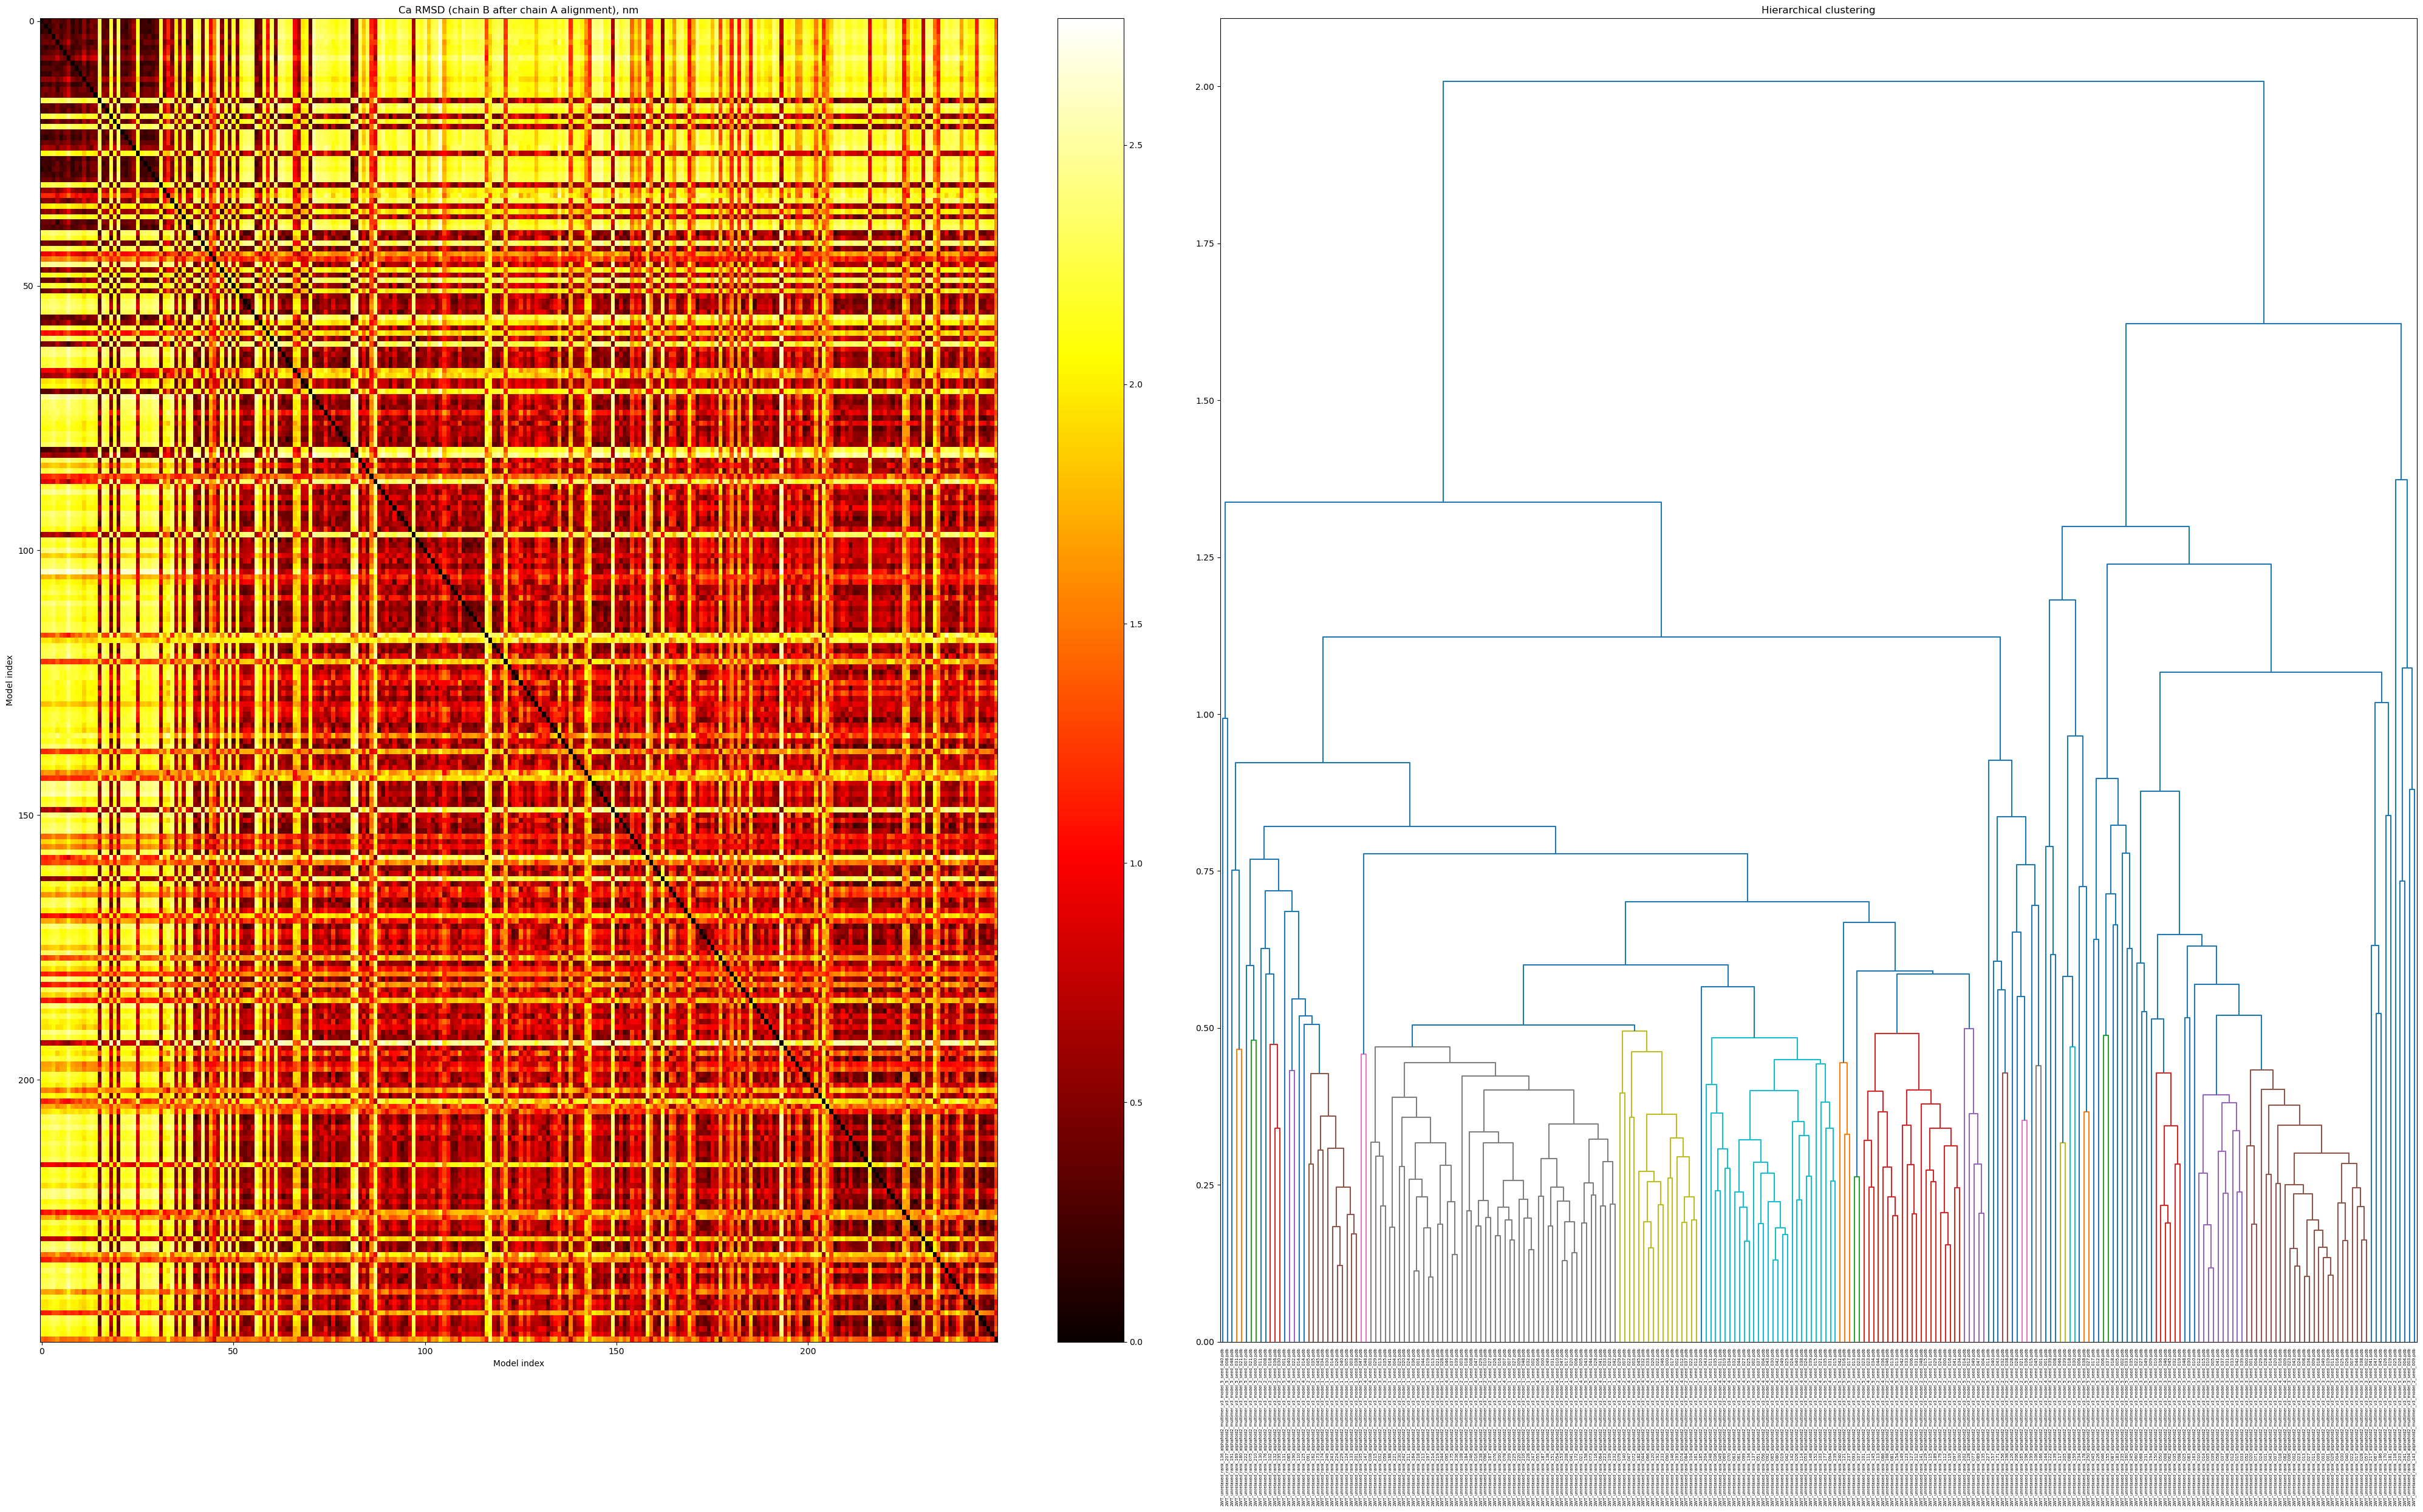

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(40, 25))

im = ax1.imshow(rmsd_matrix, cmap="hot", aspect='auto')
ax1.set_title("Ca RMSD (chain B after chain A alignment), nm")
ax1.set_xlabel("Model index")
ax1.set_ylabel("Model index")
plt.colorbar(im, ax=ax1)


dendrogram(linkage_matrix, ax=ax2, color_threshold=rmsd_cutoff, labels=[os.path.basename(f) for f in pdb_files])
ax2.set_title(f"Hierarchical clustering")
ax2.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

### DBSCAN

In [56]:
from sklearn.cluster import DBSCAN
eps_nm = 0.5 # neighboring radius for rmsd clustering
min_samples = 2 # minimum points to form a cluster

# forming distance matrix for DBSCAN
clustering = DBSCAN(eps=eps_nm, min_samples=min_samples, metric="precomputed")
db_labels = clustering.fit_predict(rmsd_matrix)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = np.sum(db_labels == -1)

In [57]:
print(n_clusters)
print(n_noise)

7
32


In [58]:
from collections import defaultdict
clusters_indices = defaultdict(list)
for idx, label in enumerate(db_labels):
    clusters_indices[label].append(idx)

In [59]:
for label, idx_list in clusters_indices.items():
    if label == -1:
        continue
    if len(idx_list) == 1:
        rep_idx = idx_list[0]
    else:
        sub = rmsd_matrix[np.ix_(idx_list, idx_list)]
        mean_rmsd = np.mean(sub, axis=1)
        rep_idx = idx_list[np.argmin(mean_rmsd)]
    out_name = f"dbscan_cluster_{label}_rep.pdb"
    models[rep_idx].save(out_name)
    print(f"Cluster with {label} had {len(idx_list)} models, saved as {out_name}")

Cluster with 0 had 48 models, saved as dbscan_cluster_0_rep.pdb
Cluster with 1 had 158 models, saved as dbscan_cluster_1_rep.pdb
Cluster with 2 had 2 models, saved as dbscan_cluster_2_rep.pdb
Cluster with 3 had 4 models, saved as dbscan_cluster_3_rep.pdb
Cluster with 4 had 2 models, saved as dbscan_cluster_4_rep.pdb
Cluster with 5 had 2 models, saved as dbscan_cluster_5_rep.pdb
Cluster with 6 had 2 models, saved as dbscan_cluster_6_rep.pdb


### DSSP calculations for DBSCAN

In [ ]:
import os
import glob
import mdtraj as md
import numpy as np


rep_dir = "."
min_strand_length = 3
rep_files = sorted(glob.glob(os.path.join(rep_dir, "dbscan_cluster_*_rep.pdb")))


candidates = []

for rep_file in rep_files:
    traj = md.load(rep_file)
    top = traj.topology
    chains = list(top.chains)
    ss = md.compute_dssp(traj, simplified=False)[0]
    print(ss)
    
    # if len(chains) < 2:
    #     continue
    # chainA = chains[0]
    # chainB = chains[1]

    # resA = [r.index for r in chainA.residues]
    # resB = [r.index for r in chainB.residues]

### iRMSD

In [37]:
import os
import glob
import numpy as np
import mdtraj as md
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict

models_dir = "./2WT" # the directory for models, should be specified
chainA_id = 0
chainB_id = 1
rmsd_cutoff = 0.3 # 3 angstroms
interface_cutoff = 1.5 # 


def get_interface_residues(traj, chainA_idx, chainB_idx, cutoff=interface_cutoff):
    top = traj.topology
    heavyA = top.select(f"chainid {chainA_idx} and not element H")
    heavyB = top.select(f"chainid {chainB_idx} and not element H")
    xyz = traj.xyz[0]
    dists = np.linalg.norm(xyz[heavyA][:, None, :] - xyz[heavyB][None, :, :], axis=2)
    close_pairs = np.where(dists < cutoff)

    if len(heavyA) == 0 or len(heavyB) == 0:
        return set(), set()
    resA = set()
    resB = set()
    for i, j in zip(close_pairs[0], close_pairs[1]):
        resA.add(top.atom(heavyA[i]).residue.index)
        resB.add(top.atom(heavyB[j]).residue.index)
    if len(close_pairs[0]) == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    else:
        return resA, resB

def build_ca_index_map(traj):
    ca_map = {}
    top = traj.topology
    for atom in top.atoms:
        if atom.name == "CA":
            res = atom.residue
            ca_map[(res.chain.index, res.index)] = atom.index
    return ca_map


def get_ca_indices_for_residues(ca_map, chain_idx, res_set):
    indices = []
    for r in sorted(res_set):
        key = (chain_idx, r)
        if key in ca_map:
            indices.append(ca_map[key])
    return np.array(indices, dtype=int)

In [38]:
pdb_files = sorted(glob.glob(os.path.join(models_dir, "*.pdb")))
models = [md.load(f) for f in pdb_files]
n_models = len(models)


interface_data = []
for i, traj in enumerate(tqdm(models, desc="Precomputing interfaces")):
    resA, resB = get_interface_residues(models[i], chainA_id, chainB_id, interface_cutoff)
    ca_map = build_ca_index_map(traj)
    interface_data.append((resA, resB, ca_map))


irmsd_matrix = np.zeros((n_models, n_models))
for i in tqdm(range(n_models)):
    resA_i, resB_i, ca_map_i = interface_data[i]
    for j in range(i+1, n_models):
        resA_j, resB_j, ca_map_j = interface_data[j]   
        commonA = resA_i & resA_j
        commonB = resB_i & resB_j

        caA_i = get_ca_indices_for_residues(ca_map_i, chainA_id, commonA)
        caB_i = get_ca_indices_for_residues(ca_map_i, chainB_id, commonB)
        caA_j = get_ca_indices_for_residues(ca_map_j, chainA_id, commonA)
        caB_j = get_ca_indices_for_residues(ca_map_j, chainB_id, commonB)

        if not (len(caA_i) == len(caA_j) == len(caB_i) == len(caB_j)):
            irmsd_matrix[i, j] = 999.0
            irmsd_matrix[j, i] = 999.0
            continue
        
        interface_i = np.concatenate([caA_i, caB_i])
        interface_j = np.concatenate([caA_j, caB_j])
        
        models[j].superpose(models[i], atom_indices=interface_j, ref_atom_indices=interface_i)
        diff = models[j].xyz[0, interface_j, :] - models[i].xyz[0, interface_i, :]
        rmsd_val = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
        irmsd_matrix[i, j] = rmsd_val
        irmsd_matrix[j, i] = rmsd_val
np.fill_diagonal(irmsd_matrix, 0)

valid_mask = np.array([len(data[0]) > 0 and len(data[1]) > 0 for data in interface_data])
if not np.any(valid_mask):
    raise RuntimeError("No models with an interface")

valid_indices = np.where(valid_mask)[0]
rmsd_sub = irmsd_matrix[np.ix_(valid_indices, valid_indices)]
dist_vec = squareform(rmsd_sub)
linkage_matrix = linkage(dist_vec, method='average')
clusters_sub = fcluster(linkage_matrix, t=rmsd_cutoff, criterion='distance')


clusters_full = -1 * np.ones(n_models, dtype=int)
clusters_full[valid_indices] = clusters_sub

n_clusters = len(set(clusters_sub))
print(n_clusters)

cluster_groups = defaultdict(list)
for idx, c in enumerate(clusters_full):
    if c != -1:
        cluster_groups[c].append(idx)

for cid, idx_list in cluster_groups.items():
    if len(idx_list) == 1:
        rep_idx = idx_list[0]
    else:
        sub = irmsd_matrix[np.ix_(idx_list, idx_list)]
        mean_dist = np.mean(sub, axis=1)
        rep_idx = idx_list[np.argmin(mean_dist)]
    out_name = f"cluster_{cid}_iRMSD_rep.pdb"
    models[rep_idx].save(out_name)
    print(f"Cluster {cid} had {len(idx_list)} models, saved as {out_name}")

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:03<00:00, 70.20it/s]


86
Cluster 42 had 44 models, saved as cluster_42_iRMSD_rep.pdb
Cluster 79 had 1 models, saved as cluster_79_iRMSD_rep.pdb
Cluster 67 had 2 models, saved as cluster_67_iRMSD_rep.pdb
Cluster 20 had 24 models, saved as cluster_20_iRMSD_rep.pdb
Cluster 77 had 1 models, saved as cluster_77_iRMSD_rep.pdb
Cluster 61 had 4 models, saved as cluster_61_iRMSD_rep.pdb
Cluster 28 had 32 models, saved as cluster_28_iRMSD_rep.pdb
Cluster 52 had 1 models, saved as cluster_52_iRMSD_rep.pdb
Cluster 46 had 1 models, saved as cluster_46_iRMSD_rep.pdb
Cluster 62 had 2 models, saved as cluster_62_iRMSD_rep.pdb
Cluster 74 had 2 models, saved as cluster_74_iRMSD_rep.pdb
Cluster 72 had 4 models, saved as cluster_72_iRMSD_rep.pdb
Cluster 54 had 3 models, saved as cluster_54_iRMSD_rep.pdb
Cluster 7 had 2 models, saved as cluster_7_iRMSD_rep.pdb
Cluster 2 had 3 models, saved as cluster_2_iRMSD_rep.pdb
Cluster 48 had 1 models, saved as cluster_48_iRMSD_rep.pdb
Cluster 64 had 3 models, saved as cluster_64_iRMSD_rep

In [30]:
clusters

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

### DSSP calculation for iRMSD

In [41]:
import os
import glob
import mdtraj as md
import numpy as np


rep_dir = "."
min_strand_length = 3
rep_files = sorted(glob.glob(os.path.join(rep_dir, "cluster_*_iRMSD_rep.pdb")))


candidates = []

for rep_file in rep_files:
    traj = md.load(rep_file)
    top = traj.topology
    chains = list(top.chains)
    ss = md.compute_dssp(traj, simplified=False)[0]
    print(ss)
    candidates.append(ss)

[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' 'S' ' ' ' ' ' ' ' ' 'E' 'E' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' 'S' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' 'S' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' 'S' ' ' ' ' ' ' ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' 'S' ' ' ' ' ' ' ' 

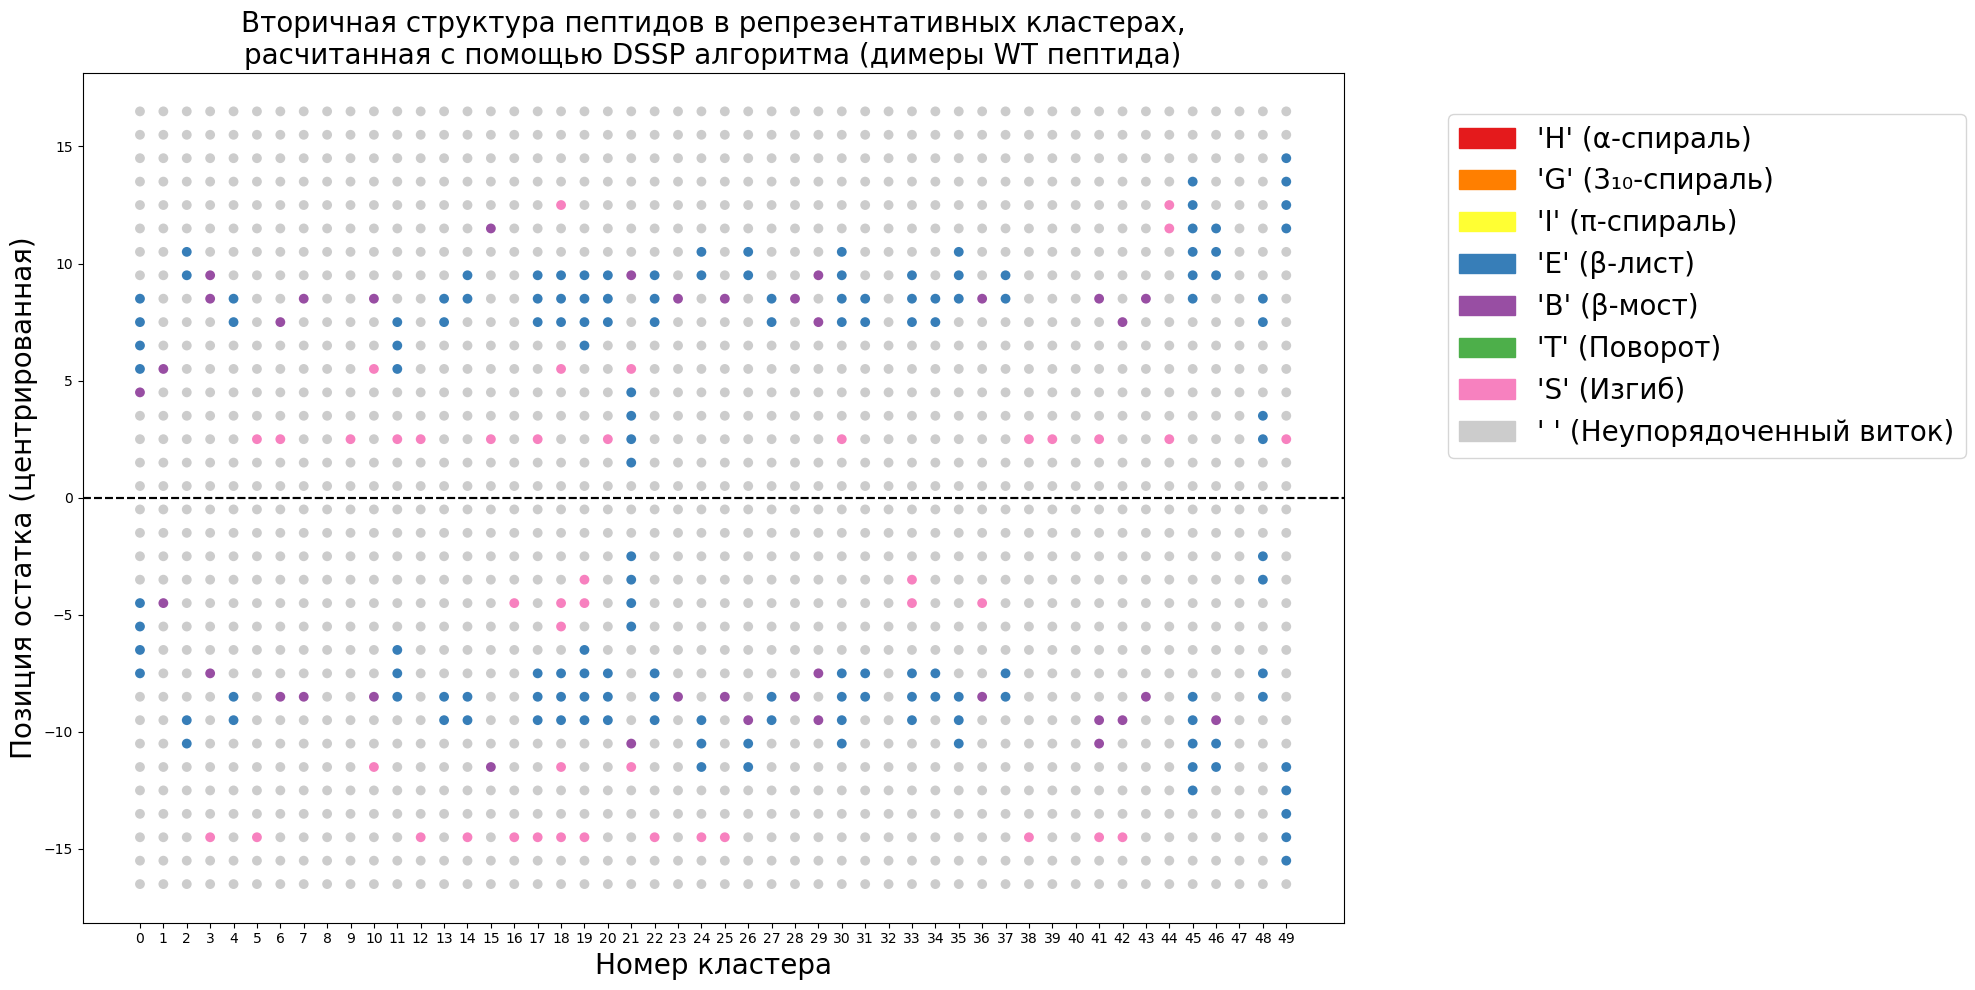

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_dssp_clusters(cluster_dssp, figsize=(20, 10), title="DSSP across clusters", peptide_length=17):
    """
    cluster_dssp : list of lists (or strings) of DSSP characters
                   e.g., [ ['E','E',' ','H',...], [' ',' ','E',...], ... ]
    """
    n_clusters = len(cluster_dssp)
    L = len(cluster_dssp[0])
    # Center residues around 0: position i -> i - (L-1)/2
    n_monomers = L // peptide_length
    y_positions = np.arange(L) - (L - 1) / 2
    # Color map for common DSSP codes
    cmap = {
        'H': '#e41a1c',   # alpha-helix (red)
        'G': '#ff7f00',   # 3-10 helix (orange)
        'I': '#ffff33',   # pi-helix (yellow)
        'E': '#377eb8',   # extended strand (blue)
        'B': '#984ea3',   # beta-bridge (purple)
        'T': '#4daf4a',   # turn (green)
        'S': '#f781bf',   # bend (pink)
        ' ': '#cccccc',   # coil / unstructured (light grey)
        '-': '#cccccc',   # alternative coil symbol
        '?': '#000000'    # unknown (black)
    }
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for i, dssp_seq in enumerate(cluster_dssp):
        if isinstance(dssp_seq, str):
            dssp_seq = list(dssp_seq)
        for j, code in enumerate(dssp_seq):
            color = cmap.get(code, '#000000')
            ax.scatter(i, y_positions[j], color=color, s=50, edgecolors='none', alpha=1)
    for k in range(1, n_monomers):
        boundary_y = (peptide_length * k - 0.5) - (L - 1) / 2
        ax.axhline(boundary_y, color='black', linestyle='--', linewidth=1.5)

    
    ax.set_xlabel("Номер кластера", fontsize=20)
    ax.set_ylabel("Позиция остатка (центрированная)", fontsize=20)
    ax.set_title(title, fontsize=20)
    ax.set_xticks(range(n_clusters))
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
    legend_patches = [mpatches.Patch(color=color, label=f"'{code}' ({name})")
                      for code, color, name in [
                          ('H', '#e41a1c', 'α-спираль'),
                          ('G', '#ff7f00', '3₁₀-спираль'),
                          ('I', '#ffff33', 'π-спираль'),
                          ('E', '#377eb8', 'β-лист'),
                          ('B', '#984ea3', 'β-мост'),
                          ('T', '#4daf4a', 'Поворот'),
                          ('S', '#f781bf', 'Изгиб'),
                          (' ', '#cccccc', 'Неупорядоченный виток'),]]
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=1.5, fontsize=20)
    plt.tight_layout()
    plt.savefig('2WT.jpg', dpi=900)
    plt.show()
plot_dssp_clusters(candidates, title="Вторичная структура пептидов в репрезентативных кластерах,\nрасчитанная с помощью DSSP алгоритма (димеры WT пептида)")

### iRMSD (multichains)

In [9]:
import os
import glob
import numpy as np
import mdtraj as md
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

models_dir = "./2WT"          # folder with your PDB files (all must have the same chain count)
interface_cutoff = 2           # nm (8 Å) – heavy-atom distance to define interface
rmsd_cutoff = 0.3                # nm (3 Å) – iRMSD threshold for clustering


def get_interface_multichain(traj, cutoff):
    """
    Returns a set of (chain_index, residue_index) tuples for residues
    whose heavy atoms are within `cutoff` of heavy atoms in a different chain.
    """
    top = traj.topology
    xyz = traj.xyz[0]
    chains = list(top.chains)
    chain_ids = [ch.index for ch in chains]
    heavy = {}
    for cid in chain_ids:
        sel = top.select(f"chainid {cid} and not element H")
        if len(sel) > 0:
            heavy[cid] = sel

    interface = set()
    chain_list = list(heavy.keys())
    for a in range(len(chain_list)):
        for b in range(a+1, len(chain_list)):
            cidA, cidB = chain_list[a], chain_list[b]
            hA, hB = heavy[cidA], heavy[cidB]
            if len(hA) == 0 or len(hB) == 0:
                continue
            dists = np.linalg.norm(xyz[hA][:, None, :] - xyz[hB][None, :, :], axis=2)
            close = np.where(dists < cutoff)
            for i, j in zip(close[0], close[1]):
                resA = top.atom(hA[i]).residue.index
                resB = top.atom(hB[j]).residue.index
                interface.add((cidA, resA)) 
                interface.add((cidB, resB))
    return interface


In [10]:
pdb_files = sorted(glob.glob(os.path.join(models_dir, "*.pdb")))
n_models = len(pdb_files)

models = []                 # list of mdtraj.Trajectory
models_ca_maps = []         # list of dict: (chain_idx, res_idx) -> CA atom index
interface_sets = []         # list of set of (chain_idx, res_idx) tuples

for f in tqdm(pdb_files, desc="Precomputing models"):
    traj = md.load(f)
    models.append(traj)
    ca_map = {}
    for atom in traj.topology.atoms:
        if atom.name == 'CA':
            res = atom.residue
            key = (res.chain.index, res.index)
            ca_map[key] = atom.index
    models_ca_maps.append(ca_map)
    iface = get_interface_multichain(traj, interface_cutoff)
    interface_sets.append(iface)


irmsd_matrix = np.zeros((n_models, n_models))
try:
    loop_range = tqdm(range(n_models), desc="iRMSD matrix")
except ImportError:
    loop_range = range(n_models)

for i in loop_range:
    set_i = interface_sets[i]
    map_i = models_ca_maps[i]
    if not set_i:
        # model has no inter‑chain contacts – mark as distant to everything
        irmsd_matrix[i, :] = 999.0
        irmsd_matrix[:, i] = 999.0
        continue

    for j in range(i+1, n_models):
        set_j = interface_sets[j]
        map_j = models_ca_maps[j]
        if not set_j:
            irmsd_matrix[i, j] = 999.0
            irmsd_matrix[j, i] = 999.0
            continue

        common = set_i & set_j   # intersection of (chain,res) tuples
        if not common:
            irmsd_matrix[i, j] = 999.0
            irmsd_matrix[j, i] = 999.0
            continue
        common_sorted = sorted(common)
        ca_i = np.array([map_i[key] for key in common_sorted])
        ca_j = np.array([map_j[key] for key in common_sorted])

        if len(ca_i) == 0 or len(ca_i) != len(ca_j):
            irmsd_matrix[i, j] = 999.0
            irmsd_matrix[j, i] = 999.0
            continue
        models[j].superpose(models[i], atom_indices=ca_j, ref_atom_indices=ca_i)
        diff = models[j].xyz[0, ca_j, :] - models[i].xyz[0, ca_i, :]
        rmsd_val = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
        irmsd_matrix[i, j] = rmsd_val
        irmsd_matrix[j, i] = rmsd_val

np.fill_diagonal(irmsd_matrix, 0)


valid_mask = np.array([len(s) > 0 for s in interface_sets])
valid_indices = np.where(valid_mask)[0]
rmsd_sub = irmsd_matrix[np.ix_(valid_indices, valid_indices)]
dist_vec = squareform(rmsd_sub)
linkage_matrix = linkage(dist_vec, method='average')
clusters_sub = fcluster(linkage_matrix, t=rmsd_cutoff, criterion='distance')

clusters_full = -1 * np.ones(n_models, dtype=int)
clusters_full[valid_indices] = clusters_sub

n_clusters = len(set(clusters_sub))
print(f"Clusters at {interface_cutoff} nm iRMSD: {n_clusters}")

cluster_groups = defaultdict(list)
for idx, c in enumerate(clusters_full):
    if c != -1:
        cluster_groups[c].append(idx)

for cid, idx_list in cluster_groups.items():
    if len(idx_list) == 1:
        rep_idx = idx_list[0]
    else:
        # choose the model with smallest mean iRMSD to others in the cluster
        sub = irmsd_matrix[np.ix_(idx_list, idx_list)]
        mean_dist = np.mean(sub, axis=1)
        rep_idx = idx_list[np.argmin(mean_dist)]
    out_name = f"cluster_{cid}_iRMSD_rep.pdb"
    models[rep_idx].save(out_name)
    print(f"Cluster {cid} with {len(idx_list)} models as {out_name}")

iRMSD matrix: 100%|████████████████████████████████████████████████████████████████████████████████| 250/250 [00:03<00:00, 66.87it/s]


Clusters at 2 nm iRMSD: 50
Cluster 17 with 44 models as cluster_17_iRMSD_rep.pdb
Cluster 39 with 92 models as cluster_39_iRMSD_rep.pdb
Cluster 38 with 9 models as cluster_38_iRMSD_rep.pdb
Cluster 10 with 1 models as cluster_10_iRMSD_rep.pdb
Cluster 4 with 1 models as cluster_4_iRMSD_rep.pdb
Cluster 36 with 10 models as cluster_36_iRMSD_rep.pdb
Cluster 12 with 3 models as cluster_12_iRMSD_rep.pdb
Cluster 6 with 1 models as cluster_6_iRMSD_rep.pdb
Cluster 41 with 23 models as cluster_41_iRMSD_rep.pdb
Cluster 46 with 1 models as cluster_46_iRMSD_rep.pdb
Cluster 8 with 1 models as cluster_8_iRMSD_rep.pdb
Cluster 14 with 6 models as cluster_14_iRMSD_rep.pdb
Cluster 28 with 6 models as cluster_28_iRMSD_rep.pdb
Cluster 29 with 2 models as cluster_29_iRMSD_rep.pdb
Cluster 30 with 5 models as cluster_30_iRMSD_rep.pdb
Cluster 27 with 2 models as cluster_27_iRMSD_rep.pdb
Cluster 50 with 1 models as cluster_50_iRMSD_rep.pdb
Cluster 3 with 2 models as cluster_3_iRMSD_rep.pdb
Cluster 42 with 1 model

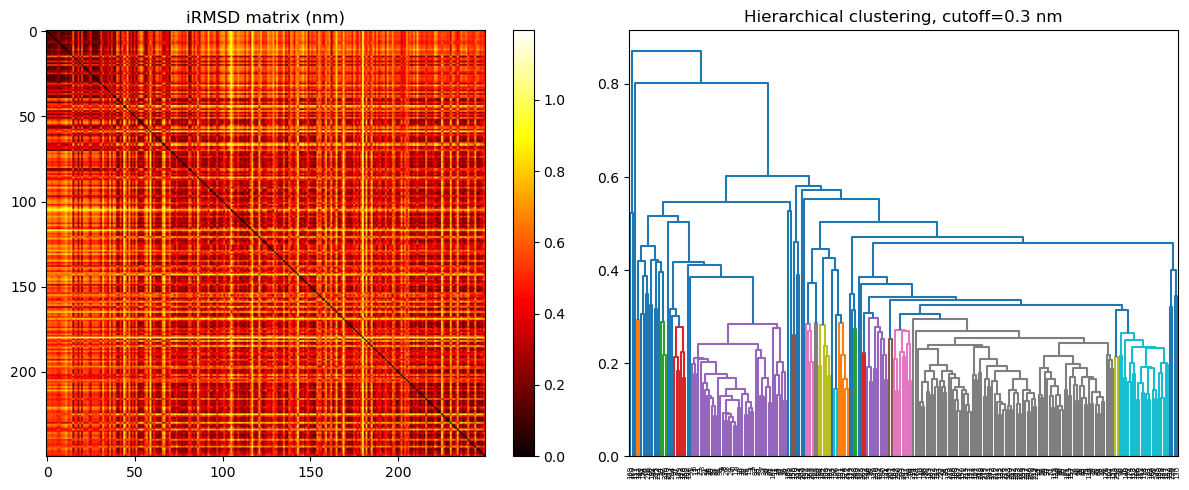

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
im = ax1.imshow(irmsd_matrix, cmap='hot', aspect='auto')
ax1.set_title("iRMSD matrix (nm)")
plt.colorbar(im, ax=ax1)

dendrogram(linkage_matrix, ax=ax2, color_threshold=rmsd_cutoff,
           labels=[str(i) for i in valid_indices])
ax2.set_title(f"Hierarchical clustering, cutoff={rmsd_cutoff} nm")
plt.tight_layout()
# plt.savefig("irmsd_clustering.png", dpi=600)
plt.show()

In [14]:
import os
import glob
import mdtraj as md
import numpy as np


rep_dir = "."
min_strand_length = 3
rep_files = sorted(glob.glob(os.path.join(rep_dir, "cluster_*_iRMSD_rep.pdb")))


candidates = []

for rep_file in rep_files:
    traj = md.load(rep_file)
    top = traj.topology
    chains = list(top.chains)
    ss = md.compute_dssp(traj, simplified=False)[0]
    print(ss)
    candidates.append(ss)

[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' 'E' 'E' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' 'B' 'E' 'E' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' 'S' ' ' ' ' ' ' ' ' ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'B' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' ' ' ' ' ' ' ' ' ' ' 'E' 'E' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' 'S' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' 'S' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
 ' ' 'S' ' ' ' ' ' ' ' ' 'B' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
[' ' ' ' ' ' ' ' ' ' ' ' ' 

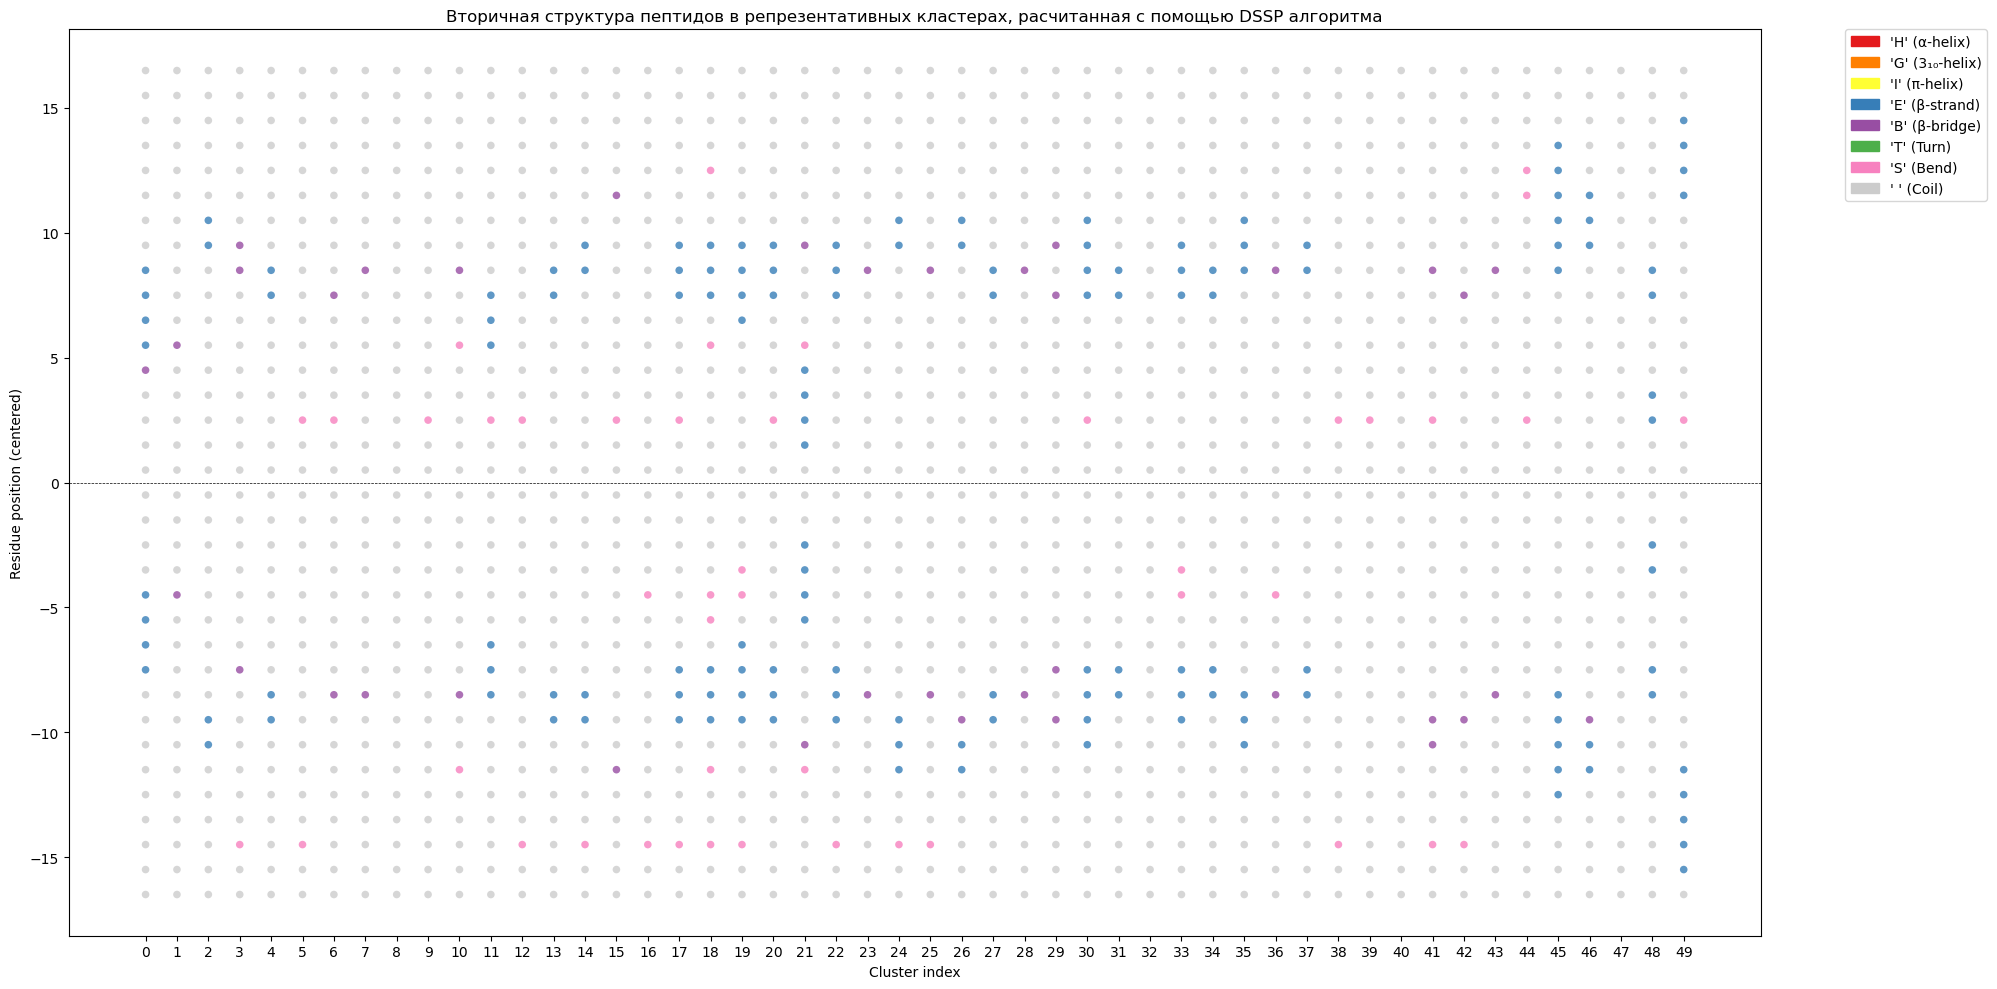

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_dssp_clusters(cluster_dssp, figsize=(20, 10), title="DSSP across clusters"):
    """
    cluster_dssp : list of lists (or strings) of DSSP characters
                   e.g., [ ['E','E',' ','H',...], [' ',' ','E',...], ... ]
    """
    n_clusters = len(cluster_dssp)
    L = len(cluster_dssp[0])
    # Center residues around 0: position i -> i - (L-1)/2
    y_positions = np.arange(L) - (L - 1) / 2

    # Color map for common DSSP codes
    cmap = {
        'H': '#e41a1c',   # alpha-helix (red)
        'G': '#ff7f00',   # 3-10 helix (orange)
        'I': '#ffff33',   # pi-helix (yellow)
        'E': '#377eb8',   # extended strand (blue)
        'B': '#984ea3',   # beta-bridge (purple)
        'T': '#4daf4a',   # turn (green)
        'S': '#f781bf',   # bend (pink)
        ' ': '#cccccc',   # coil / unstructured (light grey)
        '-': '#cccccc',   # alternative coil symbol
        '?': '#000000'    # unknown (black)
    }
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for i, dssp_seq in enumerate(cluster_dssp):
        if isinstance(dssp_seq, str):
            dssp_seq = list(dssp_seq)
        for j, code in enumerate(dssp_seq):
            color = cmap.get(code, '#000000')
            ax.scatter(i, y_positions[j], color=color, s=30, edgecolors='none', alpha=0.8)
    
    ax.set_xlabel("Cluster index")
    ax.set_ylabel("Residue position (centered)")
    ax.set_title(title)
    ax.set_xticks(range(n_clusters))
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    legend_patches = [mpatches.Patch(color=color, label=f"'{code}' ({name})")
                      for code, color, name in [
                          ('H', '#e41a1c', 'α-helix'),
                          ('G', '#ff7f00', '3₁₀-helix'),
                          ('I', '#ffff33', 'π-helix'),
                          ('E', '#377eb8', 'β-strand'),
                          ('B', '#984ea3', 'β-bridge'),
                          ('T', '#4daf4a', 'Turn'),
                          ('S', '#f781bf', 'Bend'),
                          (' ', '#cccccc', 'Coil'),]]
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

plot_dssp_clusters(candidates, title="Вторичная структура пептидов в репрезентативных кластерах, расчитанная с помощью DSSP алгоритма")